# 04 · 2-D Rotation Matrices
<sub>Math Foundations Sandbox &nbsp;·&nbsp; a hands-on geometry-for-robotics manual &nbsp;·&nbsp; run every cell top-to-bottom</sub>

---

### Recap & why now
So far we have *described* vectors. Now we start **moving** them in a controlled
way. A rotation is the first true *transformation*: it turns every vector about
the origin by an angle $\theta$ while preserving lengths and angles. Mastering
the clean 2-D case makes the 3-D case (Notebook 05) far less mysterious.

### Learning objectives
1. Derive and use the $2\times2$ rotation matrix $R(\theta)$.
2. Rotate single vectors **and whole shapes** with one matrix multiply.
3. Verify the defining properties: $R^\top R = I$ and $\det R = 1$.
4. See that the **inverse rotation is the transpose**, $R(\theta)^{-1}=R(-\theta)=R(\theta)^\top$.
5. Animate a rigid shape spinning about the origin.


In [1]:
# === Standard setup used throughout this notebook ========================
import numpy as np                 # NumPy = fast vector/matrix math, so we never hand-write loops for arithmetic.
import matplotlib.pyplot as plt     # Matplotlib is our plotting engine for every static figure below.
from matplotlib import animation   # Turns a list of frames into a playable movie (used for the animations).
from IPython.display import HTML    # Embeds an animation as a self-contained JS player (no ffmpeg required).

%matplotlib inline
# Render animations as an in-browser JavaScript player so they always play, on any machine.
plt.rcParams["animation.html"] = "jshtml"
# Raise the embed size cap (MB) so longer clips are not silently cut off.
plt.rcParams["animation.embed_limit"] = 60
# One consistent, readable look for every figure in the manual.
plt.rcParams.update({"figure.dpi": 80, "font.size": 11, "axes.grid": True})
# Print matrices with 3 decimals and no scientific notation, so output is easy to eyeball.
np.set_printoptions(precision=3, suppress=True)
print("Setup complete — NumPy", np.__version__, "| Matplotlib", plt.matplotlib.__version__)

Setup complete — NumPy 2.4.4 | Matplotlib 3.10.8


In [2]:
def draw_vector(ax, tip, tail=(0.0, 0.0), color="C0", label=None, lw=2.2):
    """Draw a 2-D vector as an arrow from `tail` to `tip`.

    Why an annotation and not ax.plot? `annotate` with arrowprops gives us a
    real arrowhead whose size stays fixed in screen space, so the arrow looks
    right no matter how the axes are zoomed.
    """
    tail = np.asarray(tail, float)                 # Accept plain tuples/lists but work in float arrays internally.
    tip  = np.asarray(tip,  float)
    ax.annotate("", xy=tip, xytext=tail,           # Empty text: we only want the arrow, not a caption here.
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                                shrinkA=0, shrinkB=0))  # shrink=0 so the arrow touches the exact endpoints.
    if label:                                      # Optionally print the vector's name near its midpoint.
        mid = tail + 0.5 * (tip - tail)            # Midpoint of the arrow, a natural spot for the label.
        ax.text(mid[0], mid[1], "  " + label, color=color,
                fontsize=12, ha="left", va="bottom")

def square_axes(ax, lim):
    """Force equal aspect + symmetric limits.

    Why: rotations and angles only *look* correct when one unit on x equals one
    unit on y. Without equal aspect a circle would render as an ellipse and a
    90-degree turn would look like something else.
    """
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim) # Symmetric window centred on the origin.
    ax.set_aspect("equal", adjustable="box")       # 1 unit in x == 1 unit in y on screen.
    ax.axhline(0, color="0.7", lw=1); ax.axvline(0, color="0.7", lw=1)  # Faint axes through the origin.

## 1 · The matrix and where it comes from

Rotating a vector by $\theta$ (counter-clockwise) is achieved by left-multiplying
it with

$$R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \phantom{-}\cos\theta \end{bmatrix}.$$

Why this matrix? Its **columns are where the basis vectors go**: the first column
is the image of $[1,0]$ and the second is the image of $[0,1]$. Since any vector
is a combination of those two, knowing where they land determines the whole map.


In [3]:
def rot2d(theta_rad):
    """Return the 2×2 counter-clockwise rotation matrix for the given angle.

    We take radians because every NumPy trig function works in radians; keeping a
    single convention avoids the classic degree/radian bug.
    """
    c_, s_ = np.cos(theta_rad), np.sin(theta_rad)   # Compute cos and sin once (cheaper and clearer).
    return np.array([[c_, -s_],                     # Column 1 = image of [1,0]; the -sin sits top-right.
                     [s_,  c_]])                     # Column 2 = image of [0,1].

R90 = rot2d(np.deg2rad(90))          # Build the 90° rotation (deg2rad converts because rot2d wants radians).
print("R(90°) =\n", R90)
print("R(90°) @ [1,0] =", R90 @ np.array([1.0, 0.0]), " ([1,0] rotates to [0,1] ✔)")  # +x -> +y.
print("R(90°) @ [0,1] =", R90 @ np.array([0.0, 1.0]), " ([0,1] rotates to [-1,0] ✔)") # +y -> -x.


R(90°) =
 [[ 0. -1.]
 [ 1.  0.]]
R(90°) @ [1,0] = [0. 1.]  ([1,0] rotates to [0,1] ✔)
R(90°) @ [0,1] = [-1.  0.]  ([0,1] rotates to [-1,0] ✔)


## 2 · Rotating a single vector

Left-multiplying a vector by $R(\theta)$ turns it. The length is unchanged — a
rotation is *rigid*. We check that numerically (the norm before and after
matches) because "did I preserve length?" is the quickest sanity test for any
rotation code.


original : [3. 1.]  length 3.1622776601683795
rotated  : [1.655 2.694]  length 3.162277660168379  (length preserved ✔)


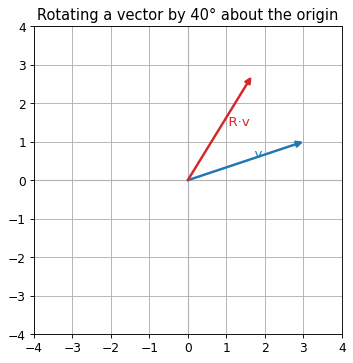

In [4]:
v = np.array([3.0, 1.0])              # The vector to rotate.
theta = np.deg2rad(40)                # Rotate by 40 degrees (converted to radians for rot2d).
v_rot = rot2d(theta) @ v              # One matrix–vector product performs the whole rotation.
print("original :", v,     " length", np.linalg.norm(v))
print("rotated  :", v_rot, " length", np.linalg.norm(v_rot), " (length preserved ✔)")

fig, ax = plt.subplots(figsize=(5, 5))
draw_vector(ax, v,     color="C0", label="v")
draw_vector(ax, v_rot, color="C3", label="R·v")
square_axes(ax, 4)
ax.set_title("Rotating a vector by 40° about the origin")
plt.show()


## 3 · Rotating a whole shape at once

A shape is just a collection of points. Stack them as the **columns** of a
$2\times N$ array and a single product $R\,P$ rotates *every* point
simultaneously. This "matrix acts on many points at once" idea is the efficiency
that makes real-time robotics graphics and transforms feasible.


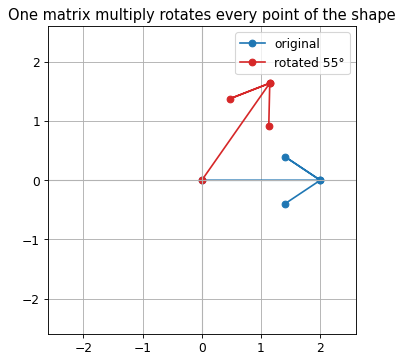

In [5]:
# An arrow-shaped "robot" so we can SEE its heading, defined as columns = points.
robot = np.array([[0.0, 2.0, 1.4, 2.0, 1.4],     # x-coordinates of the 5 outline points.
                  [0.0, 0.0, 0.4, 0.0, -0.4]])   # y-coordinates (a shaft plus an arrowhead).

theta = np.deg2rad(55)                            # Turn the robot 55°.
robot_rot = rot2d(theta) @ robot                  # ONE product rotates all 5 points together.

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(robot[0],     robot[1],     "-o", color="C0", label="original")      # Original outline.
ax.plot(robot_rot[0], robot_rot[1], "-o", color="C3", label="rotated 55°")   # Rotated outline.
square_axes(ax, 2.6); ax.legend()
ax.set_title("One matrix multiply rotates every point of the shape")
plt.show()


## 4 · The defining properties, and why the inverse is free

Rotation matrices are **orthogonal with determinant 1** — the group $SO(2)$:

* $R^\top R = I$  (columns are perpendicular unit vectors),
* $\det R = 1$  (area and orientation preserved — no reflection, no scaling).

The huge practical payoff: **the inverse is just the transpose**,
$R^{-1}=R^\top=R(-\theta)$. Undoing a rotation costs nothing but flipping the
matrix — no expensive inversion. Robotics code relies on this everywhere.


In [6]:
R = rot2d(np.deg2rad(37))                 # Any rotation will do for the checks.
print("Rᵀ R =\n", R.T @ R, " (identity ⇒ orthogonal ✔)")   # Should be the 2×2 identity.
print("det R =", np.linalg.det(R), " (1 ⇒ no scaling/reflection ✔)")  # Should be 1.0.

# The inverse equals the transpose equals the negative-angle rotation.
print("max |R⁻¹ − Rᵀ|       =", np.max(np.abs(np.linalg.inv(R) - R.T)))          # ≈0.
print("max |Rᵀ − R(−θ)|     =", np.max(np.abs(R.T - rot2d(np.deg2rad(-37)))))    # ≈0.

# Apply then undo: R(-θ) R v must return the original vector.
v = np.array([2.0, -1.0])
print("undo test:", rot2d(np.deg2rad(-37)) @ (R @ v), " vs original", v)


Rᵀ R =
 [[1. 0.]
 [0. 1.]]  (identity ⇒ orthogonal ✔)
det R = 1.0  (1 ⇒ no scaling/reflection ✔)
max |R⁻¹ − Rᵀ|       = 0.0
max |Rᵀ − R(−θ)|     = 0.0
undo test: [ 2. -1.]  vs original [ 2. -1.]


## 5 · Composition: rotations add their angles

Doing $R(\alpha)$ then $R(\beta)$ is the same as $R(\alpha+\beta)$ — in 2-D the
order does **not** matter (rotations about the same point commute here). We
confirm it, and flag now that this friendly property **breaks in 3-D**, which is
the whole drama of the next notebook.


In [7]:
Ra, Rb = rot2d(np.deg2rad(30)), rot2d(np.deg2rad(50))   # 30° and 50° rotations.
print("R(30)·R(50) − R(80):\n", Ra @ Rb - rot2d(np.deg2rad(80)))   # ≈0 ⇒ angles add up.
print("order swap R(50)·R(30) − R(30)·R(50):\n", Rb @ Ra - Ra @ Rb) # ≈0 ⇒ they commute (a 2-D-only luxury).


R(30)·R(50) − R(80):
 [[0. 0.]
 [0. 0.]]
order swap R(50)·R(30) − R(30)·R(50):
 [[0. 0.]
 [0. 0.]]


## 🧪 Try it yourself

**E1.** Rotate `v = [1, 0]` by 30°, then by another 60°, and check you land on
`[0, 1]` (i.e. 90° total).

**E2.** Write `rotate_about(points, theta, center)` that rotates a shape about an
**arbitrary point**, not the origin. (Hint: translate so `center` is at the
origin, rotate, then translate back — a preview of Notebook 07's big idea.) Test
by rotating the robot about its own nose.


after 30°+60° : [0. 1.]  (expect ≈ [0,1])


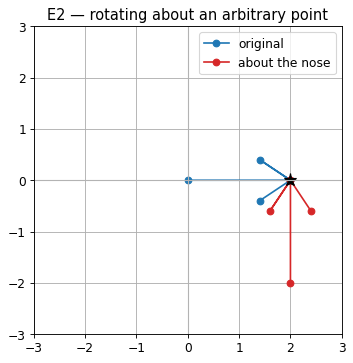

In [8]:
# --- Solution E1 -------------------------------------------------------------
v = np.array([1.0, 0.0])
step1 = rot2d(np.deg2rad(30)) @ v          # After 30°.
step2 = rot2d(np.deg2rad(60)) @ step1      # After a further 60° (90° total).
print("after 30°+60° :", step2, " (expect ≈ [0,1])")

# --- Solution E2 -------------------------------------------------------------
def rotate_about(points, theta, center):
    center = np.asarray(center, float).reshape(2, 1)    # Column vector so it broadcasts against 2×N points.
    R = rot2d(theta)
    # Shift so `center` sits at the origin, rotate there, then shift back. Rotation
    # is only defined about the origin, so we MOVE the pivot to the origin first.
    return R @ (points - center) + center

robot = np.array([[0.0, 2.0, 1.4, 2.0, 1.4],
                  [0.0, 0.0, 0.4, 0.0, -0.4]])
nose = robot[:, 1]                                        # The tip of the arrow — our pivot.
turned = rotate_about(robot, np.deg2rad(90), nose)        # Spin the robot about its own nose.

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(robot[0],  robot[1],  "-o", color="C0", label="original")
ax.plot(turned[0], turned[1], "-o", color="C3", label="about the nose")
ax.plot(*nose, "k*", ms=12)                               # Mark the pivot.
square_axes(ax, 3); ax.legend()
ax.set_title("E2 — rotating about an arbitrary point")
plt.show()


## 🚁 Mini-project: a spinning rigid body

Animate the arrow-robot rotating steadily about the origin. Because $R(\theta)$
preserves lengths and angles, the shape stays perfectly rigid — it turns without
ever deforming. That rigidity is the mathematical guarantee behind every
attitude change of a real vehicle.


In [9]:
robot = np.array([[0.0, 2.0, 1.4, 2.0, 1.4],
                  [0.0, 0.0, 0.4, 0.0, -0.4]])
n_frames = 60
spin = np.linspace(0, 2*np.pi, n_frames)     # A full revolution split into frames.

fig, ax = plt.subplots(figsize=(5, 5))
square_axes(ax, 2.6)
(line,) = ax.plot([], [], "-o", color="C3")   # Empty outline we redraw each frame.
title = ax.set_title("")

def update(i):
    turned = rot2d(spin[i]) @ robot                       # Rotate the robot to the current angle.
    line.set_data(turned[0], turned[1])                   # Update the plotted outline.
    title.set_text(f"heading = {np.degrees(spin[i]):6.1f}°")
    return line, title

anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=45, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())


> **🤖 Robotics connection.** A mobile robot's heading, a camera's roll, a wheel's
angle — each is a 2-D rotation, and steering is the act of choosing $\theta$.
The properties $R^\top R=I$ and $\det R=1$ are what let controllers invert and
compose orientations cheaply and safely. But real vehicles live in 3-D, where
rotations about different axes **do not commute** and order suddenly matters.
That is exactly the story of the next notebook: **3-D rotation matrices**.